# Figure 4d,e — Sensory composition of PSI-IhN inputs and outputs

Two heatmaps with identical structure — one row per reconstructed PSI-IhN, one column per
sensory neuron subtype, colour = that subtype's **fraction of the neuron's sensory
synapses**. Rows are grouped into the five PSI-IhN populations, separated by red dashed
lines. The strong on-diagonal blocks are the homotypic motif: each population is driven by,
and inhibits, the same sensory subtype.

| Panel | Direction | Source |
| --- | --- | --- |
| **e** | **Dendritic inputs** — sensory synapses *onto* the PSI-IhN dendrite | `data/psi_ihn_feather/dendritic_inputs/` |
| **d** | **Axoaxonic outputs** — PSI-IhN axonal synapses *onto* sensory axons | `data/psi_ihn_feather/axoaxonic_outputs/` |

**Input.** Per-neuron SPINE prediction tables (`.feather`, one row per synapse, carrying
the eight sensory subtype probabilities and a called `cell_type`). Population identity per
neuron comes from `psi_ihn_subtypes.csv`, derived from the CAVE `excitatory_neuron_label`
table. **Runs offline — no CAVE access.**

34 PSI-IhNs: 9 PSI-IhN^Aδ-HTMR, 6 Islet-PSI-IhN^C-HTMR/Heat, 6 Islet-PSI-IhN^C-LTMR,
6 Islet-PSI-IhN^Aδ-LTMR, 7 PSI-IhN^Aβ-LTMR.


In [1]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]
mpl.rcParams["svg.fonttype"] = "none"

CM = 1 / 2.54


In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

FEATHER_DIR = Path("../data/psi_ihn_feather")
SUBTYPE_CSV = FEATHER_DIR / "psi_ihn_subtypes.csv"

# SPINE writes one row per synapse. These are the subtype probability columns; a
# synapse called sensory but with every subtype probability <= this threshold is
# relabelled "low_confidence_sensory" (Methods, "Inhibitory neuron connectivity").
CLASSIFIER_COLUMNS = ["cltmr", "abltmr", "adltmr", "chtmrnp",
                      "c-htmr", "adhtmrp", "cheat", "cold"]
CONFIDENCE_THRESHOLD = 0.6

CELL_TYPES = ["Aδ-HTMR", "C-Cold", "C-HTMR", "C-HTMR-Non-peptidergic", "C-Heat",
              "N/A", "Aβ-LTMR", "Aδ-LTMR", "C-LTMR", "low_confidence_sensory"]

# CAVE `excitatory_neuron_label` tag -> published population name
POPULATION_LABELS = {
    "IN for adhtmr": "PSI-IhN Aδ-HTMR",
    "islet-chtmr":   "Islet-PSI-IhN C-HTMR/Heat",
    "islet-cltmr":   "Islet-PSI-IhN C-LTMR",
    "islet-adltmr":  "Islet-PSI-IhN Aδ-LTMR",
    "IN for abltmr": "PSI-IhN Aβ-LTMR",
}
POPULATION_ORDER = list(POPULATION_LABELS)      # top-to-bottom order in the figure


def count_synapses_by_subtype(folder):
    """One row per PSI-IhN: how many of its synapses SPINE assigned to each sensory subtype."""
    subtypes = pd.read_csv(SUBTYPE_CSV)
    coord_to_tag = dict(zip(subtypes.coord.astype(str), subtypes.tag))

    rows = []
    for f in sorted(Path(folder).glob("*.feather")):
        m = re.search(r"(\d+)_(\d+)_(\d+)", f.name)
        coord = "_".join(m.groups())
        df = pd.read_feather(f)

        low_conf = (df[CLASSIFIER_COLUMNS] <= CONFIDENCE_THRESHOLD).all(axis=1)
        df.loc[(df["is_sensory"]) & low_conf, "cell_type"] = "low_confidence_sensory"

        counts = df["cell_type"].value_counts().to_dict()
        row = {ct: counts.get(ct, 0) for ct in CELL_TYPES}
        row["coord"] = coord
        row["population"] = coord_to_tag.get(coord)
        rows.append(row)

    out = pd.DataFrame(rows).set_index("coord")
    return out[out.population.isin(POPULATION_ORDER)]


dendritic = count_synapses_by_subtype(FEATHER_DIR / "dendritic_inputs")
axoaxonic = count_synapses_by_subtype(FEATHER_DIR / "axoaxonic_outputs")

print("neurons per population:")
print(dendritic.population.value_counts().reindex(POPULATION_ORDER).to_string())
print(f"\ndendritic input synapses: {dendritic[CELL_TYPES].to_numpy().sum():,}")
print(f"axoaxonic output synapses: {axoaxonic[CELL_TYPES].to_numpy().sum():,}")


neurons per population:
population
IN for adhtmr    9
islet-chtmr      6
islet-cltmr      6
islet-adltmr     6
IN for abltmr    7

dendritic input synapses: 58,729
axoaxonic output synapses: 4,839


In [3]:
# Sensory columns shown in the figure, in column order, with published names.
SENSORY_COLUMNS = ["C-Cold", "Aδ-HTMR", "C-Heat", "C-HTMR",
                   "C-HTMR-Non-peptidergic", "C-LTMR", "Aδ-LTMR",
                   "Aβ-LTMR", "low_confidence_sensory"]

RENAME = {
    "C-Heat": "Peptidergic C-Nociceptors",
    "C-HTMR": "C-HTMR/Heat (SST)",
    "C-HTMR-Non-peptidergic": "C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)",
    "low_confidence_sensory": "Low-Confidence",
}


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


def sensory_fraction_heatmap(counts, title, out_svg):
    """Rows = neurons grouped by population, columns = sensory subtypes, colour = fraction."""
    parts = [counts[counts.population == p] for p in POPULATION_ORDER]
    ordered = pd.concat(parts)

    frac = ordered[SENSORY_COLUMNS].rename(columns=RENAME)
    frac = frac.div(frac.sum(axis=1), axis=0).fillna(0)

    sizes = [len(p) for p in parts]
    breaks = np.cumsum(sizes)[:-1]

    fig = plt.figure(figsize=(4.5 * CM, 6 * CM))
    grid = fig.add_gridspec(1, 2, width_ratios=[2.2, 10], wspace=0.0)

    # left: population labels, vertically centred on each block
    ax_lab = fig.add_subplot(grid[0, 0])
    ax_lab.set_xlim(0, 1)
    ax_lab.set_ylim(0, len(ordered))
    ax_lab.invert_yaxis()
    ax_lab.axis("off")
    start = 0
    for pop, size in zip(POPULATION_ORDER, sizes):
        ax_lab.text(0.95, start + size / 2, POPULATION_LABELS[pop],
                    va="center", ha="right", fontsize=5.5)
        start += size

    ax = fig.add_subplot(grid[0, 1])
    sns.heatmap(frac, cmap="Blues", vmin=0, vmax=1, ax=ax,
                yticklabels=False, xticklabels=True,
                cbar_kws={"label": "Sensory fraction"})
    for b in breaks:
        ax.hlines(y=b, xmin=0, xmax=frac.shape[1],
                  colors="red", linestyles="--", linewidth=0.5)

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=5.5, rotation=-50, ha="left")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=6)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=5)
    cbar.set_label("Sensory fraction", fontsize=5.5)

    fig.savefig(out_svg, format="svg", bbox_inches="tight")
    plt.show()
    return frac


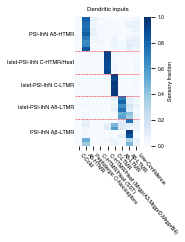

In [5]:
# ---- panel e: dendritic inputs
frac_e = sensory_fraction_heatmap(
    dendritic, "Dendritic inputs", "figure4e_dendritic_inputs_heatmap.svg")


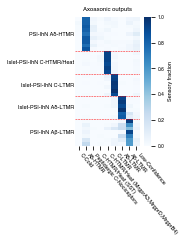

In [6]:
# ---- panel d: axoaxonic outputs
frac_d = sensory_fraction_heatmap(
    axoaxonic, "Axoaxonic outputs", "figure4d_axoaxonic_outputs_heatmap.svg")


In [7]:
# Homotypic check: for each population, the mean fraction contributed by its own
# sensory subtype, input and output side.
HOMOTYPIC_COLUMN = {
    "IN for adhtmr": "Aδ-HTMR",
    "islet-chtmr":   "C-HTMR/Heat (MrgprA3,MrgprD,MrgprB4)",
    "islet-cltmr":   "C-LTMR",
    "islet-adltmr":  "Aδ-LTMR",
    "IN for abltmr": "Aβ-LTMR",
}

print(f"{'population':30s}{'input':>10s}{'output':>10s}")
for pop in POPULATION_ORDER:
    col = HOMOTYPIC_COLUMN[pop]
    rows_e = frac_e.loc[dendritic.index[dendritic.population == pop]]
    rows_d = frac_d.loc[axoaxonic.index[axoaxonic.population == pop]]
    print(f"{POPULATION_LABELS[pop]:30s}{rows_e[col].mean():9.1%}{rows_d[col].mean():10.1%}")


population                         input    output
PSI-IhN Aδ-HTMR                   76.0%     81.3%
Islet-PSI-IhN C-HTMR/Heat         91.6%     92.2%
Islet-PSI-IhN C-LTMR              94.7%     94.8%
Islet-PSI-IhN Aδ-LTMR             65.8%     89.9%
PSI-IhN Aβ-LTMR                   49.6%     68.8%
